<a href="https://colab.research.google.com/github/tapanpaul988/Matched_filtering_ISI_eye_diagrams/blob/main/Matched_filtering%2C_ISI_and_eye_diagrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT 8 - MATCHED FILTERING, ISI AND EYE DIAGRAMS

Number of transmitted symbols = 10000
First 20 bits:
[0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]

First 20 BPSK symbols:
[-1  1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1  1  1  1 -1]

FILTER DELAY VALIDATION
RRC filter length       : 129 samples
TX filter delay         : 64 samples
Matched filter delay    : 64 samples
Total cascade delay    : 128 samples
Expected total delay in symbols: 8.0

BER at SNR = 10 dB : 0.0


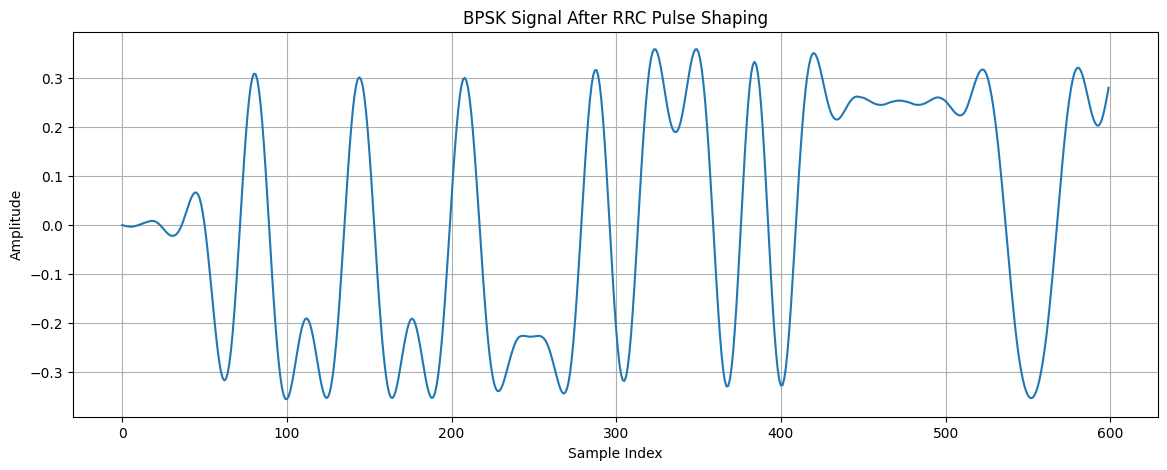

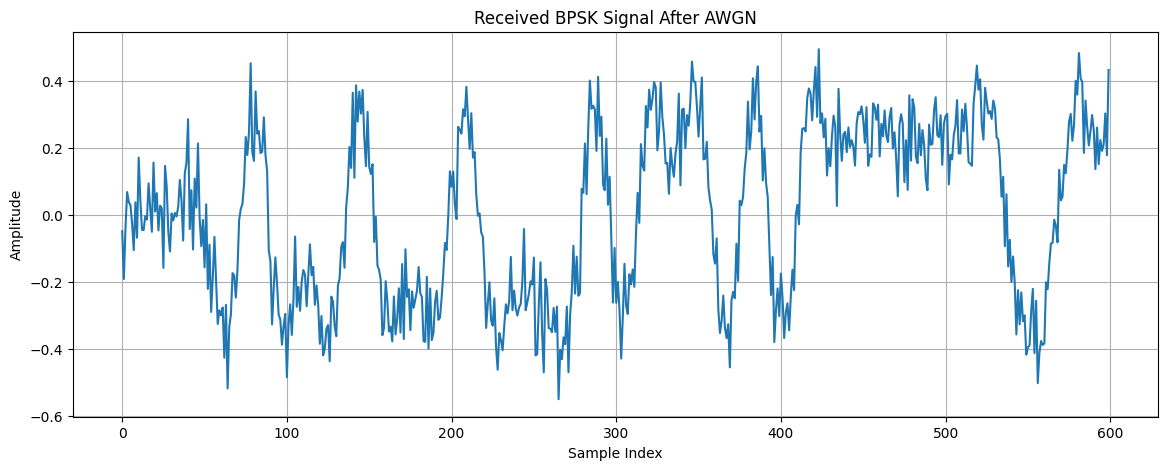

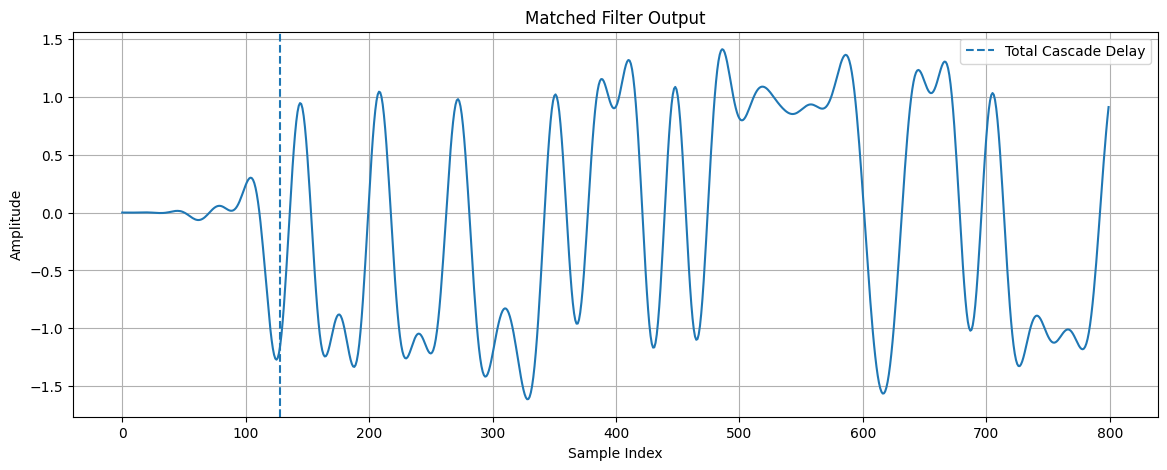


MANDATORY VALIDATION
Total cascade delay = 128 samples

First 10 transmitted symbols:
[-1  1 -1 -1 -1  1 -1 -1 -1  1]

Matched-filter samples AFTER delay compensation:
[-1.146  0.946 -1.05  -0.881 -1.136  1.045 -0.976 -1.046 -0.928  0.98 ]

Detected bits:
[0 1 0 0 0 1 0 0 0 1]

Original bits:
[0 1 0 0 0 1 0 0 0 1]

Symbols are detected only after removing the total
TX + RX matched-filter cascade delay.


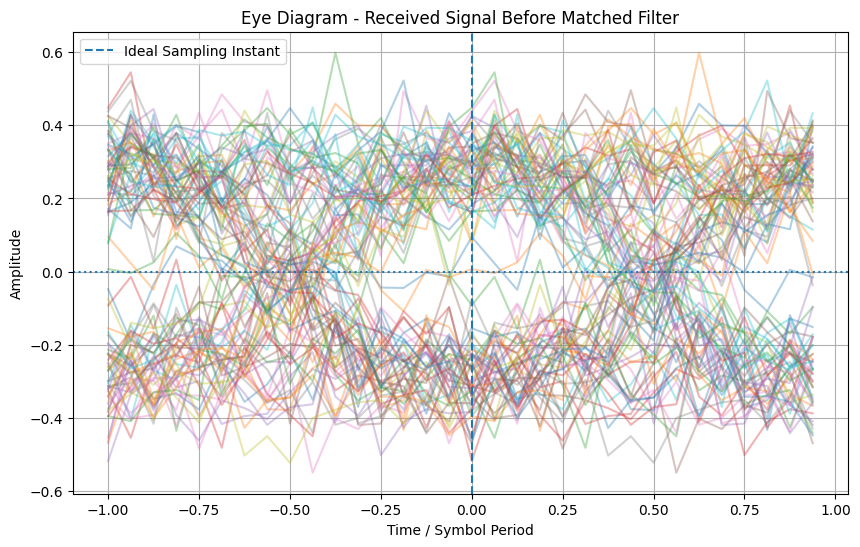

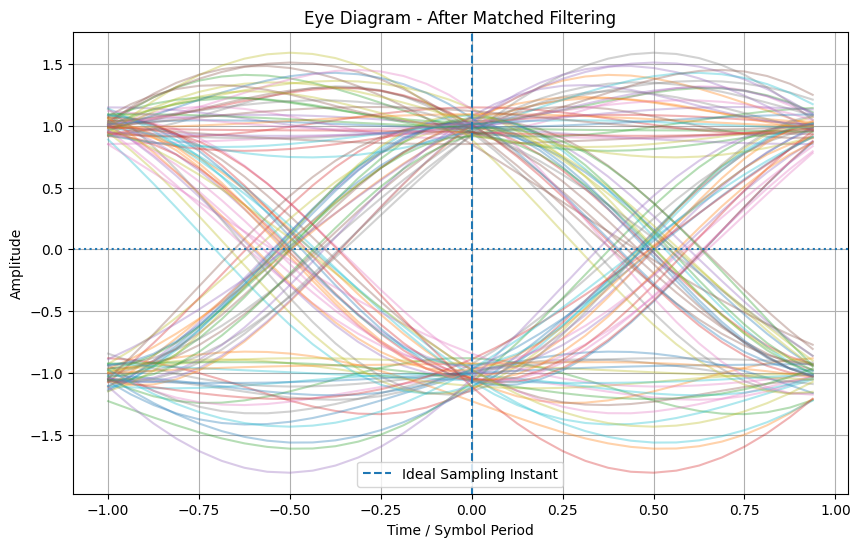

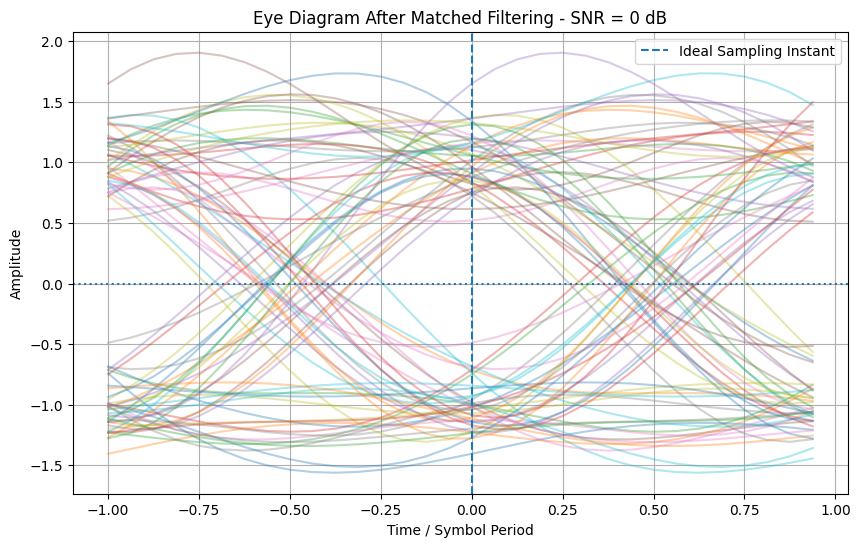

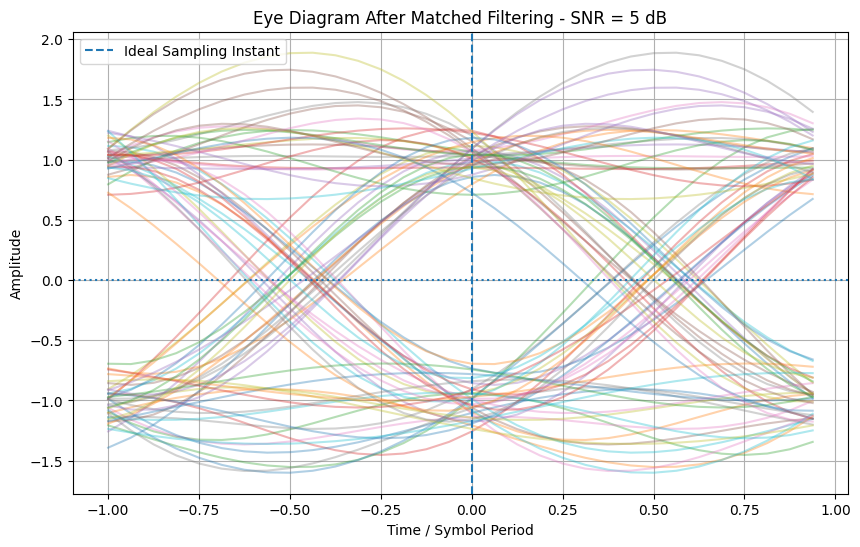

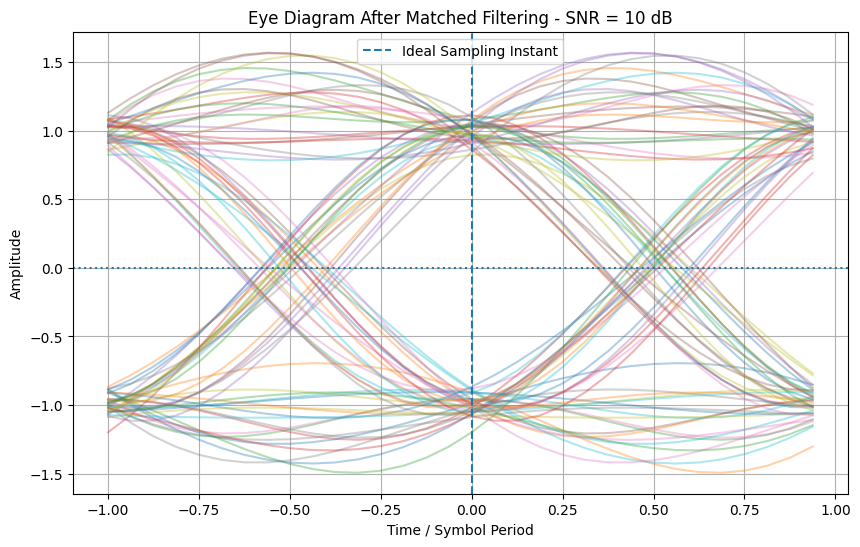

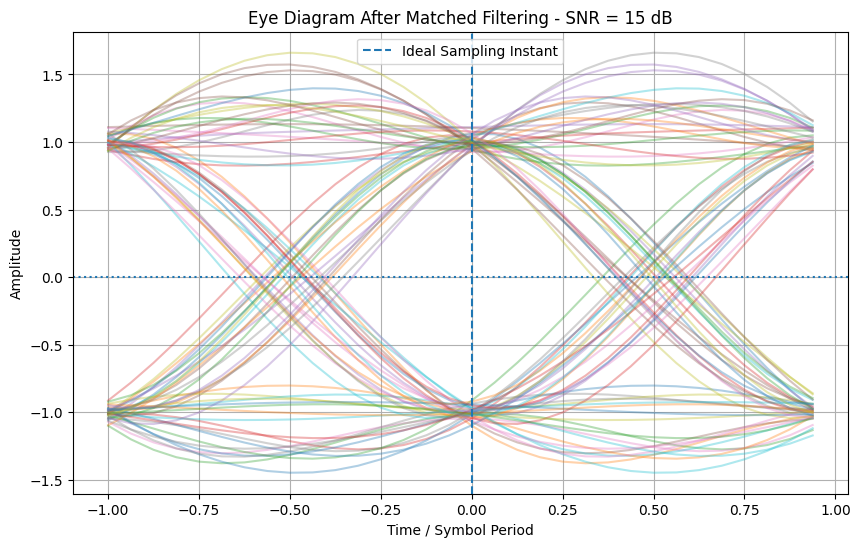

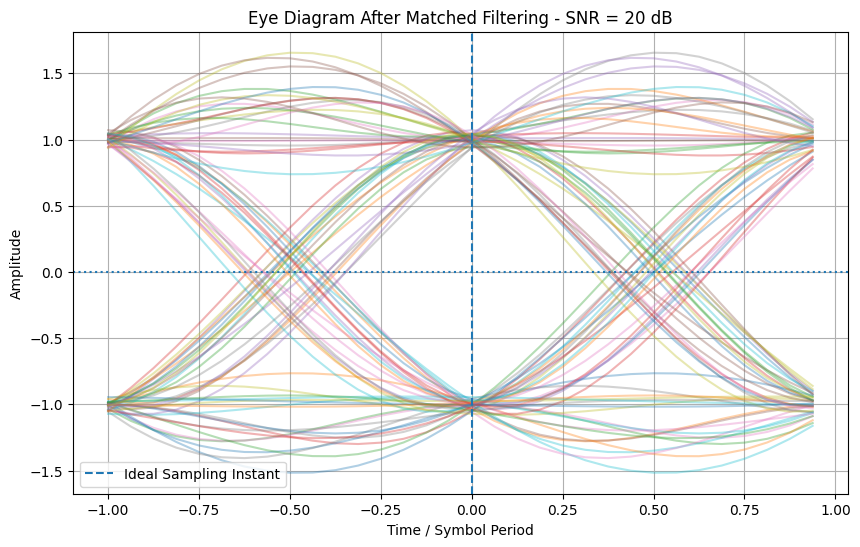

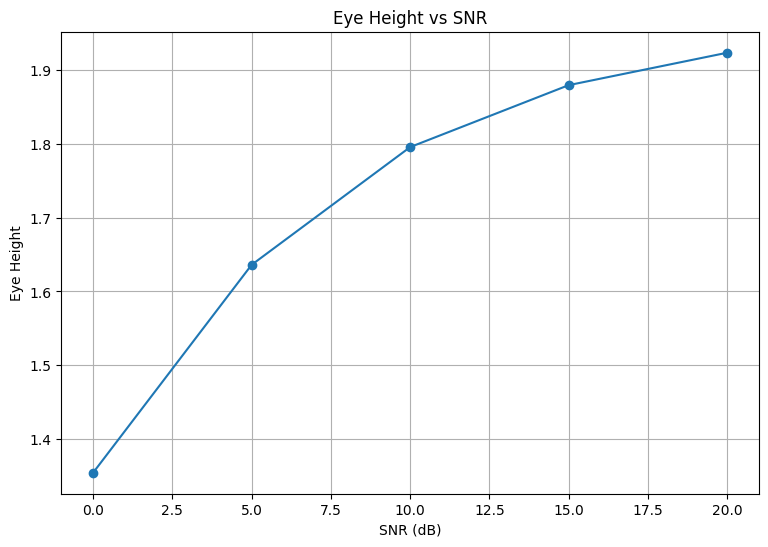


SNR VARIATION RESULTS


,SNR (dB),Eye Height,BER
0,0,1.3539,0.0
1,5,1.6361,0.0
2,10,1.7959,0.0
3,15,1.8800,0.0
4,20,1.9240,0.0


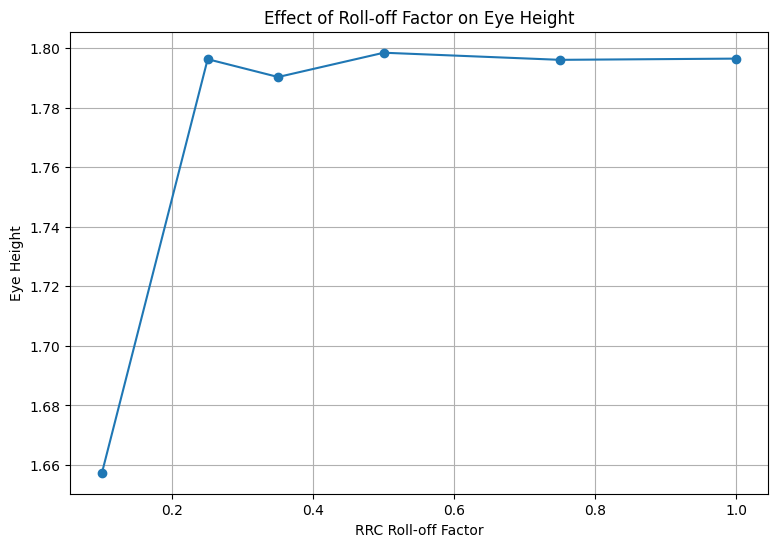

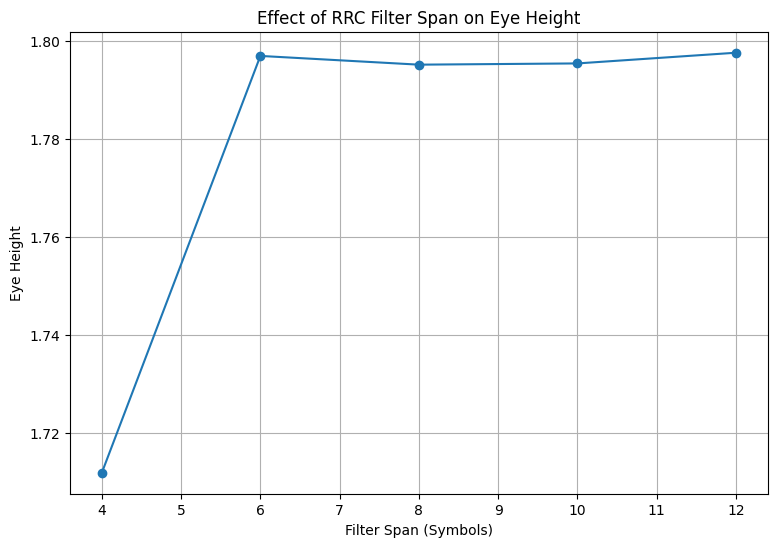

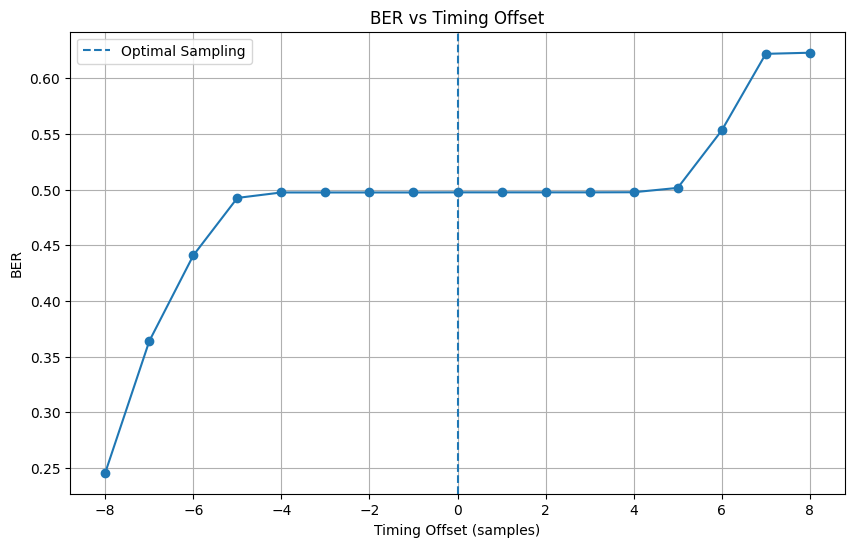


MULTIPATH CHANNEL
Multipath delay = 12 samples
Multipath delay = 0.75 symbol periods
Channel coefficients:
[1.  0.5]


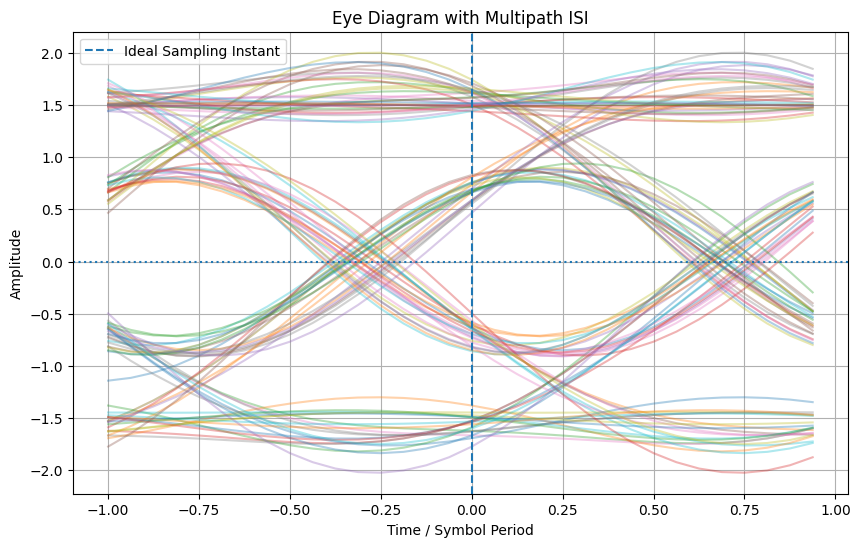


BER with multipath ISI = 0.0


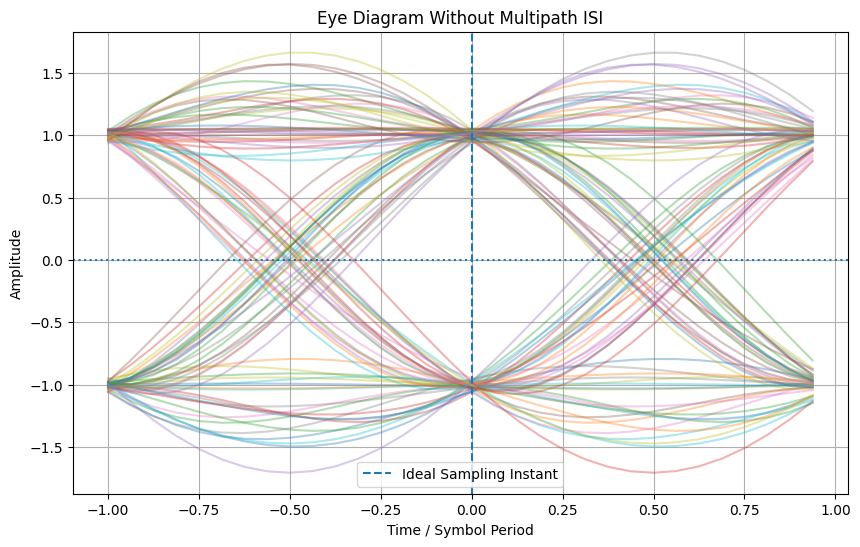


FINAL EXPERIMENT PARAMETERS AND RESULTS


,Parameter,Value
0,Number of Symbols,10000.00
1,Samples/Symbol,16.00
2,RRC Roll-off,0.35
3,RRC Span,8.00
4,SNR,10.00
5,RRC Filter Length,129.00
6,Single Filter Delay,64.00
7,Total Cascade Delay,128.00
8,BER,0.00



OBSERVATION AND INTERPRETATION

1. MATCHED FILTERING
--------------------
The receiver uses a filter matched to the transmitted RRC pulse.
The matched filter maximizes the signal-to-noise ratio at the
correct sampling instant.

2. CASCADE DELAY
----------------
The RRC transmit filter introduces a group delay equal to half
of its filter length minus one.

The receive matched filter introduces the same delay.

Therefore:

    Total Delay = TX Filter Delay + RX Filter Delay

The detected symbols must be sampled only after removing this
total delay.

3. EYE DIAGRAM
--------------
A wide and open eye indicates that the received symbols can be
sampled reliably.

Noise causes the eye to become vertically less open.

Timing errors cause the eye to become more closed horizontally.

4. SNR EFFECT
-------------
As SNR increases, noise decreases and the eye becomes clearer.
The BER generally decreases with increasing SNR.

5. ROLL-OFF FACTOR
------------------
The roll-off factor controls excess

In [1]:
# ================================================================
# EXPERIMENT 8
# MATCHED FILTERING, ISI AND EYE DIAGRAMS
#
# BPSK + RRC Pulse Shaping + AWGN + Matched Filter
#
# Compatible with Google Colab
# No Communication Toolbox required
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

# ================================================================
# 1. BASIC PARAMETERS
# ================================================================

N_BITS = 10000          # Number of BPSK symbols
SPS = 16                # Samples per symbol
ROLL_OFF = 0.35         # RRC roll-off factor
SPAN = 8                # Filter span in symbols
SNR_DB = 10             # Main simulation SNR

print("=" * 70)
print("EXPERIMENT 8 - MATCHED FILTERING, ISI AND EYE DIAGRAMS")
print("=" * 70)

# ================================================================
# 2. RRC FILTER FUNCTION
# ================================================================

def rrc_filter(beta, span, sps):
    """
    Generate a Root Raised Cosine (RRC) filter.

    beta : roll-off factor
    span : filter length in symbols
    sps  : samples per symbol
    """

    N = span * sps
    t = np.arange(-N/2, N/2 + 1) / sps

    h = np.zeros(len(t))

    for i, ti in enumerate(t):

        # Special case: t = 0
        if abs(ti) < 1e-12:
            h[i] = 1 + beta * (4/np.pi - 1)

        # Special case: t = +/- T/(4*beta)
        elif beta > 0 and abs(abs(ti) - 1/(4*beta)) < 1e-12:

            h[i] = (beta / np.sqrt(2)) * (
                (1 + 2/np.pi) * np.sin(np.pi/(4*beta))
                +
                (1 - 2/np.pi) * np.cos(np.pi/(4*beta))
            )

        else:

            numerator = (
                np.sin(np.pi * ti * (1 - beta))
                +
                4 * beta * ti * np.cos(np.pi * ti * (1 + beta))
            )

            denominator = (
                np.pi * ti * (1 - (4 * beta * ti)**2)
            )

            h[i] = numerator / denominator

    # Normalize energy
    h = h / np.sqrt(np.sum(h**2))

    return h


# ================================================================
# 3. BPSK GENERATION
# ================================================================

bits = np.random.randint(0, 2, N_BITS)

# BPSK mapping:
# bit 0 -> -1
# bit 1 -> +1

symbols = 2 * bits - 1

print("\nNumber of transmitted symbols =", N_BITS)
print("First 20 bits:")
print(bits[:20])

print("\nFirst 20 BPSK symbols:")
print(symbols[:20])


# ================================================================
# 4. UPSAMPLING
# ================================================================

upsampled = np.zeros(N_BITS * SPS)

upsampled[::SPS] = symbols


# ================================================================
# 5. TRANSMISSION FUNCTION
# ================================================================

def transmit_bpsk(
    symbols,
    sps=16,
    beta=0.35,
    span=8,
    snr_db=10,
    channel=None
):

    # ------------------------------------------------------------
    # RRC transmit filter
    # ------------------------------------------------------------

    rrc = rrc_filter(beta, span, sps)

    # Upsample
    up = np.zeros(len(symbols) * sps)
    up[::sps] = symbols

    # Pulse shaping
    tx = np.convolve(up, rrc, mode='full')

    # ------------------------------------------------------------
    # Optional multipath channel
    # ------------------------------------------------------------

    if channel is not None:
        tx_channel = np.convolve(tx, channel, mode='full')
    else:
        tx_channel = tx.copy()

    # ------------------------------------------------------------
    # AWGN
    # ------------------------------------------------------------

    signal_power = np.mean(tx_channel**2)

    noise_power = signal_power / (10**(snr_db / 10))

    noise = np.sqrt(noise_power) * np.random.randn(len(tx_channel))

    rx = tx_channel + noise

    return tx, rx, rrc


# ================================================================
# 6. RECEIVER WITH MATCHED FILTER
# ================================================================

def matched_filter_receiver(rx, rrc):

    # Matched filter = time-reversed RRC filter
    matched = rrc[::-1]

    mf_output = np.convolve(rx, matched, mode='full')

    return mf_output


# ================================================================
# 7. MAIN BPSK TRANSMISSION
# ================================================================

tx_signal, rx_signal, rrc = transmit_bpsk(
    symbols,
    sps=SPS,
    beta=ROLL_OFF,
    span=SPAN,
    snr_db=SNR_DB
)

mf_output = matched_filter_receiver(rx_signal, rrc)


# ================================================================
# 8. CALCULATE FILTER DELAY
# ================================================================

filter_length = len(rrc)

single_filter_delay = (filter_length - 1) // 2

total_cascade_delay = 2 * single_filter_delay

print("\n" + "=" * 70)
print("FILTER DELAY VALIDATION")
print("=" * 70)

print("RRC filter length       :", filter_length, "samples")
print("TX filter delay         :", single_filter_delay, "samples")
print("Matched filter delay    :", single_filter_delay, "samples")
print("Total cascade delay    :", total_cascade_delay, "samples")

print("Expected total delay in symbols:",
      total_cascade_delay / SPS)


# ================================================================
# 9. SYMBOL SAMPLING AFTER DELAY COMPENSATION
# ================================================================

sample_indices = (
    total_cascade_delay
    + np.arange(N_BITS) * SPS
)

# Keep only valid samples
valid = sample_indices < len(mf_output)

sample_indices = sample_indices[valid]

detected_samples = mf_output[sample_indices.astype(int)]

detected_bits = (detected_samples >= 0).astype(int)

original_bits = bits[:len(detected_bits)]


# ================================================================
# 10. BER CALCULATION
# ================================================================

BER = np.mean(detected_bits != original_bits)

print("\nBER at SNR =", SNR_DB, "dB :", BER)


# ================================================================
# 11. NORMALIZE MATCHED FILTER OUTPUT
# ================================================================

# Estimate amplitude from received symbols
scale = np.mean(
    detected_samples * symbols[:len(detected_samples)]
)

if abs(scale) > 1e-12:
    normalized_samples = detected_samples / scale
else:
    normalized_samples = detected_samples


# ================================================================
# 12. PLOT TRANSMITTED BPSK SIGNAL
# ================================================================

plt.figure(figsize=(14, 5))

display_samples = min(600, len(tx_signal))

plt.plot(tx_signal[:display_samples])

plt.title("BPSK Signal After RRC Pulse Shaping")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()


# ================================================================
# 13. PLOT RECEIVED SIGNAL
# ================================================================

plt.figure(figsize=(14, 5))

display_samples = min(600, len(rx_signal))

plt.plot(rx_signal[:display_samples])

plt.title("Received BPSK Signal After AWGN")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()


# ================================================================
# 14. PLOT MATCHED FILTER OUTPUT
# ================================================================

plt.figure(figsize=(14, 5))

display_samples = min(
    800,
    len(mf_output)
)

plt.plot(mf_output[:display_samples])

# Show cascade delay
plt.axvline(
    total_cascade_delay,
    linestyle='--',
    label='Total Cascade Delay'
)

plt.title("Matched Filter Output")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()


# ================================================================
# 15. VALIDATION OF DELAY COMPENSATION
# ================================================================

print("\n" + "=" * 70)
print("MANDATORY VALIDATION")
print("=" * 70)

print("Total cascade delay =", total_cascade_delay, "samples")

print("\nFirst 10 transmitted symbols:")
print(symbols[:10])

print("\nMatched-filter samples AFTER delay compensation:")

print(np.round(
    detected_samples[:10],
    3
))

print("\nDetected bits:")
print(detected_bits[:10])

print("\nOriginal bits:")
print(original_bits[:10])

print("\nSymbols are detected only after removing the total")
print("TX + RX matched-filter cascade delay.")


# ================================================================
# 16. EYE DIAGRAM FUNCTION
# ================================================================

def plot_eye(signal, sps, n_traces=100, title="Eye Diagram"):

    samples_per_trace = 2 * sps

    center = sps

    max_start = len(signal) - samples_per_trace

    if max_start <= 0:
        print("Signal too short for eye diagram.")
        return

    starts = np.arange(
        0,
        max_start,
        sps
    )

    if len(starts) > n_traces:
        starts = starts[:n_traces]

    time_axis = np.arange(samples_per_trace) / sps - 1

    plt.figure(figsize=(10, 6))

    for start in starts:

        segment = signal[
            start:start + samples_per_trace
        ]

        if len(segment) == samples_per_trace:

            plt.plot(
                time_axis,
                segment,
                alpha=0.35
            )

    plt.axvline(
        0,
        linestyle='--',
        label='Ideal Sampling Instant'
    )

    plt.axhline(
        0,
        linestyle=':'
    )

    plt.title(title)
    plt.xlabel("Time / Symbol Period")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()

    plt.show()


# ================================================================
# 17. EYE DIAGRAM BEFORE MATCHED FILTER
# ================================================================

plot_eye(
    rx_signal,
    SPS,
    n_traces=100,
    title="Eye Diagram - Received Signal Before Matched Filter"
)


# ================================================================
# 18. EYE DIAGRAM AFTER MATCHED FILTER
# ================================================================

# Remove the initial cascade delay
eye_signal = mf_output[
    total_cascade_delay:
]

plot_eye(
    eye_signal,
    SPS,
    n_traces=100,
    title="Eye Diagram - After Matched Filtering"
)


# ================================================================
# 19. EYE DIAGRAM FOR DIFFERENT SNRs
# ================================================================

snr_values = [0, 5, 10, 15, 20]

for snr in snr_values:

    tx, rx, rrc_temp = transmit_bpsk(
        symbols,
        sps=SPS,
        beta=ROLL_OFF,
        span=SPAN,
        snr_db=snr
    )

    mf = matched_filter_receiver(
        rx,
        rrc_temp
    )

    delay = 2 * ((len(rrc_temp) - 1) // 2)

    mf_valid = mf[delay:]

    plot_eye(
        mf_valid,
        SPS,
        n_traces=80,
        title=f"Eye Diagram After Matched Filtering - SNR = {snr} dB"
    )


# ================================================================
# 20. EYE HEIGHT CALCULATION
# ================================================================

def calculate_eye_height(signal, sps):

    sampling_point = sps

    values = signal[
        sampling_point::sps
    ]

    values = values[
        np.isfinite(values)
    ]

    positive = values[values > 0]
    negative = values[values < 0]

    if len(positive) == 0 or len(negative) == 0:
        return np.nan

    # Robust eye-opening estimate
    upper_level = np.percentile(
        positive,
        10
    )

    lower_level = np.percentile(
        negative,
        90
    )

    eye_height = upper_level - lower_level

    return eye_height


# ================================================================
# 21. EYE HEIGHT VS SNR
# ================================================================

eye_heights = []
ber_values = []

for snr in snr_values:

    tx, rx, rrc_temp = transmit_bpsk(
        symbols,
        sps=SPS,
        beta=ROLL_OFF,
        span=SPAN,
        snr_db=snr
    )

    mf = matched_filter_receiver(
        rx,
        rrc_temp
    )

    delay = 2 * ((len(rrc_temp) - 1) // 2)

    samples = mf[
        delay:delay + N_BITS * SPS
    ]

    # Eye height
    eh = calculate_eye_height(
        samples,
        SPS
    )

    eye_heights.append(eh)

    # Symbol detection
    sample_values = samples[::SPS]

    usable = min(
        len(sample_values),
        len(bits)
    )

    bits_detected = (
        sample_values[:usable] >= 0
    ).astype(int)

    ber = np.mean(
        bits_detected != bits[:usable]
    )

    ber_values.append(ber)


# ================================================================
# 22. PLOT EYE HEIGHT VS SNR
# ================================================================

plt.figure(figsize=(9, 6))

plt.plot(
    snr_values,
    eye_heights,
    marker='o'
)

plt.xlabel("SNR (dB)")
plt.ylabel("Eye Height")
plt.title("Eye Height vs SNR")
plt.grid(True)

plt.show()


# ================================================================
# 23. PRINT SNR RESULTS
# ================================================================

snr_table = pd.DataFrame({
    "SNR (dB)": snr_values,
    "Eye Height": np.round(eye_heights, 4),
    "BER": np.round(ber_values, 6)
})

print("\n" + "=" * 70)
print("SNR VARIATION RESULTS")
print("=" * 70)

display(snr_table)


# ================================================================
# 24. ROLL-OFF FACTOR VARIATION
# ================================================================

rolloff_values = [0.1, 0.25, 0.35, 0.5, 0.75, 1.0]

rolloff_eye = []

for beta in rolloff_values:

    tx, rx, rrc_temp = transmit_bpsk(
        symbols,
        sps=SPS,
        beta=beta,
        span=SPAN,
        snr_db=10
    )

    mf = matched_filter_receiver(
        rx,
        rrc_temp
    )

    delay = 2 * ((len(rrc_temp) - 1) // 2)

    valid_signal = mf[delay:]

    eh = calculate_eye_height(
        valid_signal,
        SPS
    )

    rolloff_eye.append(eh)


# ================================================================
# 25. PLOT ROLL-OFF EFFECT
# ================================================================

plt.figure(figsize=(9, 6))

plt.plot(
    rolloff_values,
    rolloff_eye,
    marker='o'
)

plt.xlabel("RRC Roll-off Factor")
plt.ylabel("Eye Height")
plt.title("Effect of Roll-off Factor on Eye Height")
plt.grid(True)

plt.show()


# ================================================================
# 26. FILTER SPAN VARIATION
# ================================================================

span_values = [4, 6, 8, 10, 12]

span_eye = []

for span in span_values:

    tx, rx, rrc_temp = transmit_bpsk(
        symbols,
        sps=SPS,
        beta=ROLL_OFF,
        span=span,
        snr_db=10
    )

    mf = matched_filter_receiver(
        rx,
        rrc_temp
    )

    delay = 2 * ((len(rrc_temp) - 1) // 2)

    valid_signal = mf[delay:]

    eh = calculate_eye_height(
        valid_signal,
        SPS
    )

    span_eye.append(eh)


# ================================================================
# 27. PLOT FILTER SPAN EFFECT
# ================================================================

plt.figure(figsize=(9, 6))

plt.plot(
    span_values,
    span_eye,
    marker='o'
)

plt.xlabel("Filter Span (Symbols)")
plt.ylabel("Eye Height")
plt.title("Effect of RRC Filter Span on Eye Height")
plt.grid(True)

plt.show()


# ================================================================
# 28. TIMING OFFSET ANALYSIS
# ================================================================

timing_offsets = np.arange(
    -SPS // 2,
    SPS // 2 + 1
)

timing_ber = []

# Use one clean/noisy matched filter output
tx, rx, rrc_temp = transmit_bpsk(
    symbols,
    sps=SPS,
    beta=ROLL_OFF,
    span=SPAN,
    snr_db=10
)

mf = matched_filter_receiver(
    rx,
    rrc_temp
)

delay = 2 * ((len(rrc_temp) - 1) // 2)

aligned = mf[
    delay:
]

for offset in timing_offsets:

    start = SPS + offset

    if start < 0:
        timing_ber.append(np.nan)
        continue

    sample_values = aligned[
        start::SPS
    ]

    usable = min(
        len(sample_values),
        len(bits)
    )

    detected = (
        sample_values[:usable] >= 0
    ).astype(int)

    ber = np.mean(
        detected != bits[:usable]
    )

    timing_ber.append(ber)


# ================================================================
# 29. BER VS TIMING OFFSET
# ================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    timing_offsets,
    timing_ber,
    marker='o'
)

plt.axvline(
    0,
    linestyle='--',
    label='Optimal Sampling'
)

plt.xlabel("Timing Offset (samples)")
plt.ylabel("BER")
plt.title("BER vs Timing Offset")
plt.grid(True)
plt.legend()

plt.show()


# ================================================================
# 30. MULTIPATH ISI CHANNEL
# ================================================================

# Multipath channel:
#
# Main path      = 1
# Delayed path   = 0.5
#
# Delay = 0.75 symbol approximately

multipath_delay = int(0.75 * SPS)

channel = np.zeros(
    multipath_delay + 1
)

channel[0] = 1.0
channel[multipath_delay] = 0.5


print("\n" + "=" * 70)
print("MULTIPATH CHANNEL")
print("=" * 70)

print("Multipath delay =", multipath_delay, "samples")
print("Multipath delay =",
      multipath_delay / SPS,
      "symbol periods")

print("Channel coefficients:")
print(channel[channel != 0])


# ================================================================
# 31. TRANSMISSION THROUGH MULTIPATH CHANNEL
# ================================================================

tx_mp, rx_mp, rrc_mp = transmit_bpsk(
    symbols,
    sps=SPS,
    beta=ROLL_OFF,
    span=SPAN,
    snr_db=20,
    channel=channel
)

mf_mp = matched_filter_receiver(
    rx_mp,
    rrc_mp
)

delay_mp = 2 * (
    (len(rrc_mp) - 1) // 2
)

aligned_mp = mf_mp[
    delay_mp:
]


# ================================================================
# 32. MULTIPATH EYE DIAGRAM
# ================================================================

plot_eye(
    aligned_mp,
    SPS,
    n_traces=100,
    title="Eye Diagram with Multipath ISI"
)


# ================================================================
# 33. MULTIPATH BER
# ================================================================

mp_samples = aligned_mp[
    ::SPS
]

usable = min(
    len(mp_samples),
    len(bits)
)

mp_detected = (
    mp_samples[:usable] >= 0
).astype(int)

mp_ber = np.mean(
    mp_detected != bits[:usable]
)

print("\nBER with multipath ISI =", mp_ber)


# ================================================================
# 34. IDEAL / NO-ISI COMPARISON
# ================================================================

tx_clean, rx_clean, rrc_clean = transmit_bpsk(
    symbols,
    sps=SPS,
    beta=ROLL_OFF,
    span=SPAN,
    snr_db=20
)

mf_clean = matched_filter_receiver(
    rx_clean,
    rrc_clean
)

delay_clean = 2 * (
    (len(rrc_clean) - 1) // 2
)

aligned_clean = mf_clean[
    delay_clean:
]

plot_eye(
    aligned_clean,
    SPS,
    n_traces=100,
    title="Eye Diagram Without Multipath ISI"
)


# ================================================================
# 35. FINAL RESULTS TABLE
# ================================================================

results = pd.DataFrame({
    "Parameter": [
        "Number of Symbols",
        "Samples/Symbol",
        "RRC Roll-off",
        "RRC Span",
        "SNR",
        "RRC Filter Length",
        "Single Filter Delay",
        "Total Cascade Delay",
        "BER"
    ],

    "Value": [
        N_BITS,
        SPS,
        ROLL_OFF,
        SPAN,
        SNR_DB,
        len(rrc),
        single_filter_delay,
        total_cascade_delay,
        BER
    ]
})


print("\n" + "=" * 70)
print("FINAL EXPERIMENT PARAMETERS AND RESULTS")
print("=" * 70)

display(results)


# ================================================================
# 36. AUTOMATIC OBSERVATIONS
# ================================================================

print("\n" + "=" * 70)
print("OBSERVATION AND INTERPRETATION")
print("=" * 70)

print("""
1. MATCHED FILTERING
--------------------
The receiver uses a filter matched to the transmitted RRC pulse.
The matched filter maximizes the signal-to-noise ratio at the
correct sampling instant.

2. CASCADE DELAY
----------------
The RRC transmit filter introduces a group delay equal to half
of its filter length minus one.

The receive matched filter introduces the same delay.

Therefore:

    Total Delay = TX Filter Delay + RX Filter Delay

The detected symbols must be sampled only after removing this
total delay.

3. EYE DIAGRAM
--------------
A wide and open eye indicates that the received symbols can be
sampled reliably.

Noise causes the eye to become vertically less open.

Timing errors cause the eye to become more closed horizontally.

4. SNR EFFECT
-------------
As SNR increases, noise decreases and the eye becomes clearer.
The BER generally decreases with increasing SNR.

5. ROLL-OFF FACTOR
------------------
The roll-off factor controls excess bandwidth.

A larger roll-off factor generally produces a wider transition
band and changes the shape of the eye and pulse response.

6. FILTER SPAN
--------------
Increasing filter span gives a better approximation to the
ideal RRC pulse but increases the number of filter coefficients
and therefore the delay.

7. TIMING OFFSET
---------------
The best sampling point occurs near the center of the eye.

Moving away from the optimum sampling instant increases the
probability of decision errors.

8. MULTIPATH ISI
----------------
The delayed copy of the transmitted signal interferes with the
main signal.

This produces inter-symbol interference (ISI), reducing eye
opening and potentially increasing BER.

9. CONCLUSION
-------------
The experiment demonstrates that matched filtering, correct
delay compensation and proper timing synchronization are
essential for reliable BPSK reception.
""")

print("=" * 70)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 70)